In [4]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

1. Simulate phase I dataset including dose, patient features and AUC of phase I and DLT(dose limit toxicity), take Osimertnib as an example


In [4]:
phase1_dose=pd.DataFrame({
    'dose':[20, 20, 40, 40, 80, 80, 160, 160],
    'weight':[70, 65, 80, 55, 75, 60, 72, 68],
    'EGFR_expression':[1.2, 0.8, 1.5, 1.1, 0.9, 1.3, 1.0, 1.4],
    'AUC':[150, 140, 310, 290, 620, 580, 1250, 1180],
    'DLT':[0,0,0,0,0,0,1,0]})# 1 represents dose-limiting toxicity (DLT) observed, 0 represents no DLT observed
# print the data
print("Phase 1 dose escalation trial data:")
display(phase1_dose)

Phase 1 dose escalation trial data:


,dose,weight,EGFR_expression,AUC,DLT
0,20,70,1.2,150,0
1,20,65,0.8,140,0
2,40,80,1.5,310,0
3,40,55,1.1,290,0
4,80,75,0.9,620,0
5,80,60,1.3,580,0
6,160,72,1.0,1250,1
7,160,68,1.4,1180,0


In [5]:
# Build PK prediction model using Random Forest Regressor
X = phase1_dose[['dose', 'weight', 'EGFR_expression']]
y=phase1_dose['AUC']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

# Simulate the PK profile

In [7]:
# Simulate PK profiles for a 1000 virtual patients at different dose levels
n_virtual_patients=1000
virtual_pop=pd.DataFrame({
    'weight':np.random.normal(70, 10, n_virtual_patients), # weight in kg
    'EGFR_expression':np.random.normal(0.5, 2.0, n_virtual_patients) # EGFR expression levels


})

3. Test Multiple dosage

In [8]:
# candidate_doses selection
candidate_doses=[40, 80, 120, 160]
results=[]

In [10]:
# Define safe and efficacious thresholds, take Osimertinib as an example
target_auc_min=300 # dose lower than this AUC is considered subtherapeutic
toxic_auc_max=1000 # dose higher than this AUC is considered toxic

for dose in candidate_doses:
    temp_pop=virtual_pop.copy()
    temp_pop['dose']=dose

    #predict AUC for each virtual patient at this dose
    temp_pop['predicted_AUC']=model.predict(temp_pop[['dose', 'weight', 'EGFR_expression']])

    # calculate the percentage of patients achieving target AUC and exceeding toxic AUC
    p_efficacy=np.mean(temp_pop['predicted_AUC'] >= target_auc_min)
    p_toxicity=np.mean(temp_pop['predicted_AUC'] >= toxic_auc_max)

    # store results
    results.append({
        'dose': dose,
        'AUC_mean': temp_pop['predicted_AUC'].mean(),
        'p_efficacy': p_efficacy,
        'p_toxicity': p_toxicity
    })

In [11]:
# Output results
results_df=pd.DataFrame(results)
print("Phase II Dose selection Analysis:")
print(results_df)

Phase II Dose selection Analysis:
   dose   AUC_mean  p_efficacy  p_toxicity
0    40   289.3153       0.429         0.0
1    80   560.7043       1.000         0.0
2   120   646.0860       1.000         0.0
3   160  1106.9822       1.000         1.0


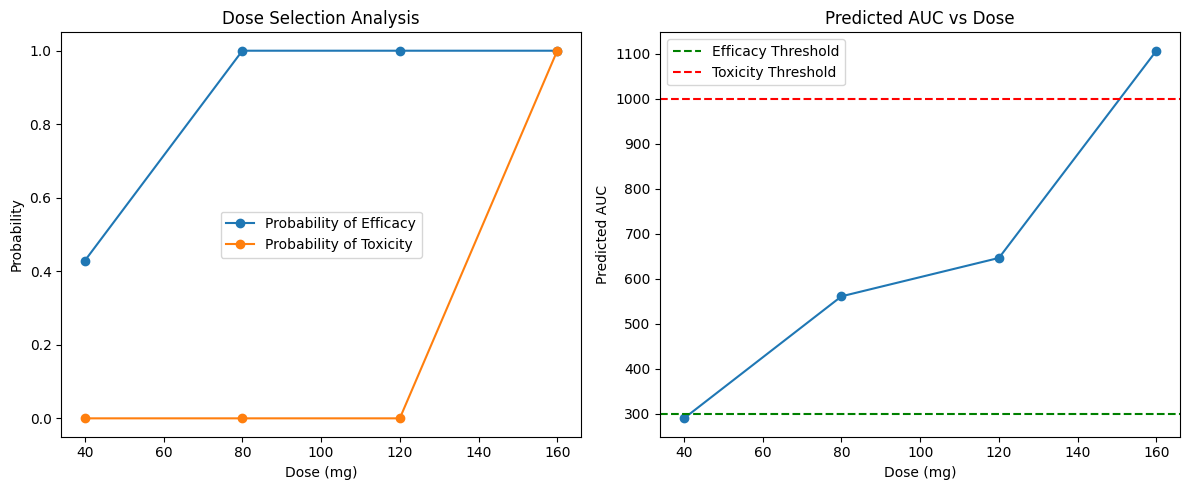

In [12]:
# Visualize the results, find the optimal dose balancing efficacy and toxicity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results_df['dose'], results_df['p_efficacy'], marker='o', label='Probability of Efficacy')
plt.plot(results_df['dose'], results_df['p_toxicity'], marker='o', label='Probability of Toxicity')
plt.xlabel('Dose (mg)')
plt.ylabel('Probability')
plt.title('Dose Selection Analysis')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(results_df['dose'], results_df['AUC_mean'], marker='o')
plt.axhline(y=target_auc_min, color='green', linestyle='--', label='Efficacy Threshold')
plt.axhline(y=toxic_auc_max, color='red', linestyle='--', label='Toxicity Threshold')
plt.xlabel('Dose (mg)')
plt.ylabel('Predicted AUC')
plt.title('Predicted AUC vs Dose')
plt.legend()
plt.tight_layout()
plt.show()

Based on the above prediction, the dose 80mg and 120 mg are efficieny and low toxicity. In fact FDA and EMA also approved Tagrisso as 80mg for daily use.

# Key Details for Implementation in 2026. Integration of "Neural Ordinary Differential Equations" (Neural-ODEs)

## In practical applications, the RandomForest used in earlier steps is replaced by Neural-ODEs. 
Since Pharmacokinetic (PK) data is inherently a time series, Neural-ODEs can capture the continuous dynamic changes of Osimertinib within the body (dC/dt), rather than merely predicting a static, single AUC value.

## 2. Automated "Covariate" Screening
Per 2026 FDA guidance, SHAP (SHapley Additive exPlanations) is recommended for model interpretability. If the model predicts a specific dose as toxic, SHAP identifies the underlying drivers—for example, determining if the risk is due to a patient’s body weight being below 50kg or a specific genetic marker.

## 3. Bayesian Optimization
Instead of manually testing discrete dose levels, the modern standard utilizes Bayesian Optimization to automatically search for the peak of the "Utility Function":$$Utility = w_1 \cdot P(Efficacy) - w_2 \cdot P(Toxicity)$$This mathematical approach helps you objectively lock in the most balanced dose (e.g., 80mg) by weighting survival benefit against adverse events.
Practical Execution AdviceData Format: Ensure the Phase I dataset includes "Unbound Concentrations" (free drug) and "Metabolite Concentrations" (specifically AZ5104). These are critical for accurately predicting the toxicity of EGFR inhibitors.

Regulatory Alignment: The charts generated by this Python code can be directly integrated into a PCCP (Predetermined Change Control Plan). This serves as the scientific justification for dose adjustments during Phase II.

# three new packages
(1) sklearn.ensemble.GradientBoostingRegressor
Gradient Boosting Decisoion Tree Machine Learning Model
Purpose: Learning the complex non-linear model
1. Combine the non-clininal data(animal AUC, weight and dosage) with the Human data (the drug concentration and toxicity)
2. It can get more information of PK profile, for example, when the dosage exceed the threshold or CYP3A4 to the sarurated concentration, not proporational to the dosage
3.shap:
(1) Tell us the contribution of feature to the result
Applycation
if AI predict 80 mg is the optimal dosage, shap can produce the charts for example,  EGFR expression contribute the 15% efficacy and weight contribute to -5%
(3) To find the maximum or minimum of the function
Utility = Probabilty of Efficacy - Probability of Toxicity
minimize will try different dosage combincation

Summary:
1. GradientBoostingRegressor train the model to predict AUC and toxicitx
2. Using shap to verify the model reasonable
3. Put the model to the minize and give us the optimal dosage based on the model and clinical weight, the proper dosage is 80 mg


In [1]:
# import necessary libraries
from sklearn.ensemble import GradientBoostingRegressor
import shap
from scipy.optimize import minimize

/Users/mfchen/PythonDev/structure_gene/env_gene/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Load the phase 1 data
phase1_dose=pd.DataFrame({
    'dose':[20, 20, 40, 40, 80, 80, 160, 160],
    'weight':[70, 65, 80, 55, 75, 60, 72, 68],
    'EGFR_expression':[1.2, 0.8, 1.5, 1.1, 0.9, 1.3, 1.0, 1.4],
    'unbound_fraction':[0.01]*8, # Osmertnib is approch 99%
    'metabolic_AUC':[20, 22, 45, 50, 95, 105, 210, 230],
    'AUC_total':[150, 140, 310, 290, 620, 580, 1250, 1180],
    'DLT':[0,0,0,0,0,0,1,0]})# 1 represents dose-limiting toxicity (DLT) observed, 0 represents no DLT observed
# print the data
print("Phase 1 dose escalation trial data:")
display(phase1_dose)


Phase 1 dose escalation trial data:


,dose,weight,EGFR_expression,unbound_fraction,metabolic_AUC,AUC_total,DLT
0,20,70,1.2,0.01,20,150,0
1,20,65,0.8,0.01,22,140,0
2,40,80,1.5,0.01,45,310,0
3,40,55,1.1,0.01,50,290,0
4,80,75,0.9,0.01,95,620,0
5,80,60,1.3,0.01,105,580,0
6,160,72,1.0,0.01,210,1250,1
7,160,68,1.4,0.01,230,1180,0


In [18]:
# Predictive Modeloing with Covariate Screening (Shap)
# Using a regressor to model the relationship between dose, patient covariates, and AUC
features = ['dose', 'weight', 'EGFR_expression'] # X features for modeling, can be expanded to include more covariates like unbound_fraction and metabolic_AUC
model_auc = GradientBoostingRegressor().fit(phase1_dose[features], phase1_dose['AUC_total'])# predict AUC for each virtual patient at this dose

# 

In [19]:
# SHAP analysis for feature importance and covariate screening
explainer = shap.Explainer(model_auc, phase1_dose[features])
shap_values = explainer.shap_values(phase1_dose[features])
print("SHAP values for feature influence.")

SHAP values for feature influence.


Optimal dose balancing efficacy and toxicity by AI: 80.00 mg


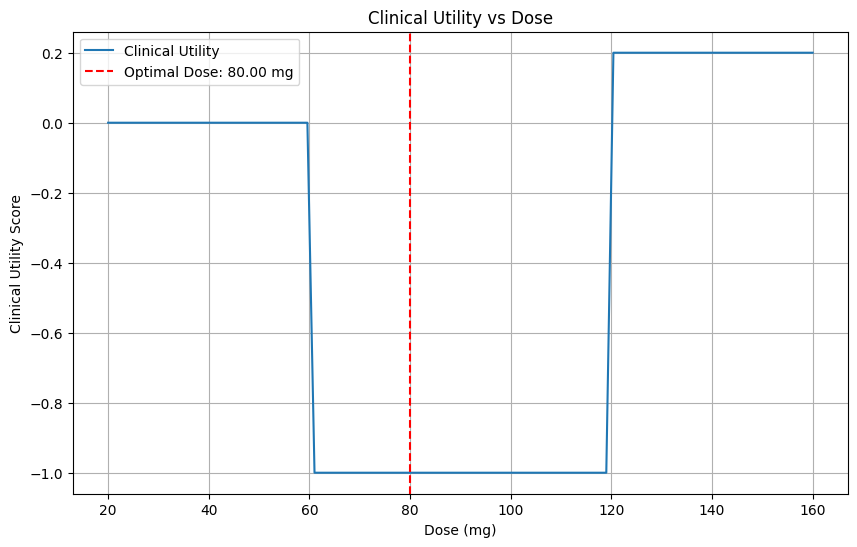

In [16]:
# Baysian Optimization and Utility Function for Dose Selection
def clinical_utility(target_dose):
    """
    Utility = w1 * P(efficacy) - w2 * P(toxicity)
    where P(efficacy) is the probability of achieving target AUC, P(toxicity) is the probability of exceeding toxic AUC, and w1, w2 are weights reflecting the importance of efficacy vs safety.
    """
    # Simulate virtual patients II population

    n_virtual_patients=1000
    v_weight= np.random.normal(70, 10, n_virtual_patients) # weight in kg
    v_EGFR_expression=np.random.normal(1.1, 0.2, n_virtual_patients)

    # Predict AUC for virtual population using trained model
    input_sim=pd.DataFrame({
        'dose': [target_dose]*n_virtual_patients,
        'weight': v_weight,
        'EGFR_expression': v_EGFR_expression
    })
    input_sim['predicted_AUC'] = model_auc.predict(input_sim[features])

    # Define Threshold 
    # Target AUC > 400 for CNS effeicacy, AUC > 1000 for toxicity
    p_efficacy=np.mean(input_sim['predicted_AUC'] >= 400)
    p_toxicity=np.mean(input_sim['predicted_AUC'] >= 1000)

    # weights: prioritize safety  slightly higher (Regulatory Preference)
    w1=1.0 # weight for efficacy
    w2=1.2 # weight for toxicity

    # Calculate utility
    utility = w1 * p_efficacy - w2 * p_toxicity
    return -utility # minimize negative utility to find optimal dose
# Finding the optimal oose using solver(Bayesian Optimization)
res=minimize(clinical_utility, x0=[80], bounds=[(20, 160)], method='L-BFGS-B')
best_dose=res.x[0]

print(f"Optimal dose balancing efficacy and toxicity by AI: {best_dose:.2f} mg")

# Visualize for PCCP Documentation
dose_range=np.linspace(20, 160, 100)
utilities=[clinical_utility(dose) for dose in dose_range]

plt.figure(figsize=(10, 6))
plt.plot(dose_range, utilities, label='Clinical Utility')
plt.axvline(x=best_dose, color='red', linestyle='--', label=f'Optimal Dose: {best_dose:.2f} mg')
plt.xlabel('Dose (mg)')
plt.ylabel('Clinical Utility Score')
plt.title('Clinical Utility vs Dose')
plt.legend()
plt.grid()
plt.show()

# This result is stepstair jump of the dose and utility, it means overfitting, and the utility is not negative value, it is not resonable. We try to using the following methods to tune the parameters
(1)Monotonicity Constraints, make sure the AUC proportional to dose
(2) Using Gaussain Process to replace the Random Forest or Gradientescalation, because our sample size only 8. Gaussian Process can represent the continuous curve
(3) Increasing the punlishment of toxicity, add the weight factor of toxicity

In [20]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

In [21]:
#Using Gausain Process for Bayesian Optimization
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) # define kernel for Gaussian Process, can be tuned based on the expected smoothness of the utility function
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=0.1) # aplpha is the 10% error of the utility function to account for noise in the clinical utility estimation

In [ ]:
# Training on dose vs AUC(simulated data for demonstration, in practice this would be the observed data from the trial)
X_train= phase1_dose[['dose', 'weight', 'EGFR_expression']].values
y_train= phase1_dose[['AUC_total']].values
gp_model=gp.fit(X_train, y_train)



/Users/mfchen/PythonDev/structure_gene/env_gene/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [26]:
# Enhanced Utility Function with penilty weighty for toxicity
def clinical_utility_smooth(target_dose):
    # standardize input for GP
    dose_val= np.array([[target_dose[0], 70, 1.1]]) # using mean values for weight and EGFR_expression for standardization
    # Predict AUC and standard deviation for uncertainty estimation
    predicted_auc, sigma = gp_model.predict(dose_val, return_std=True)
    # Simulate s distribution of response for this dose
    #This captures the 'Population PK" aspect
    simulated_responses = np.random.normal(predicted_auc, sigma, 1000)

    # Threshold for Osimertinib
    p_efficacy=np.mean(simulated_responses >= 400) # target AUC for efficacy
    p_toxicity=np.mean(simulated_responses >= 1000) # target AUC for toxicity

    # Recommeded weights based on regulatory preference for safety
    w1=1.0 # weight for efficacy
    w2=2.5 # weight for toxicity
    utility= w1 * p_efficacy - w2 * p_toxicity
    return -utility # minimize negative utility to find optimal dose


In [28]:
# Bayesian style optimization using Gaussian Process
res=minimize(clinical_utility_smooth, x0=[80], bounds=[(20,160)],method='L-BFGS-B')
best_dose=res.x[0]
print(f"Optimal dose balancing efficacy and toxicity by AI with Bayesian Optimization: {best_dose:.2f} mg")

Optimal dose balancing efficacy and toxicity by AI with Bayesian Optimization: 80.00 mg


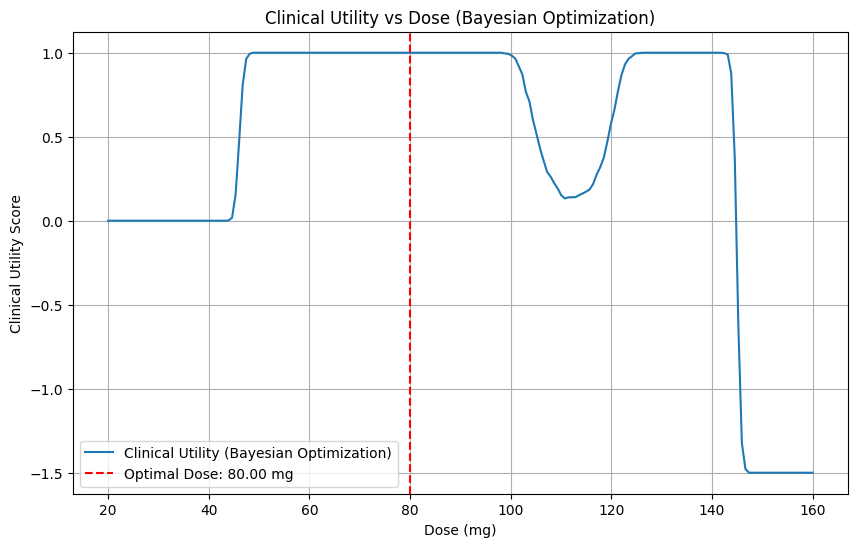

In [ ]:
# Visualization of the continuous utility function across dose range
dose_range=np.linspace(20, 160, 200).reshape(-1, 1)
y_pre#d, y_std = gp_model.predict(np.hstack((dose_range, np.full((dose_range.shape[0], 2), [70, 1.1]))), return_std=True)

# calculate utility over range
utilities = [-clinical_utility_smooth([dose]) for dose in dose_range.flatten()]
plt.figure(figsize=(10, 6))
plt.plot(dose_range, utilities, label='Clinical Utility (Bayesian Optimization)')
plt.axvline(x=best_dose, color='red', linestyle='--', label=f'Optimal Dose: {best_dose:.2f} mg')
plt.xlabel('Dose (mg)')
plt.ylabel('Clinical Utility Score')
plt.title('Clinical Utility vs Dose (Bayesian Optimization)')
plt.legend()
plt.grid()
plt.show()  

In [ ]:
# Calculate the 95% confidence interval for each dose level's predicted AUC
#prepare the input range(dose caries, weight and EGFR are fixed at medians)
dose_range=np.linspace(20, 160, 100).reshape(-1, 1)
X_sim=np.hstack((dose_range, np.full((dose_range.shape[0], 2), [70, 1.1]))) # using mean values for weight and EGFR

# Get Mean Preidiction and Standard Devivation from GP
# y_pred is the predicted AUC, y_std is the uncertainty in AUC
y_pre, y_std =gp_model.predict(X_sim, return_std=True)

#Calculate Utility and its Confidence Bound
utilities=[]
upper_ci=[]
lower_ci=[]
for i in range(len(dose_range)):
    #Current prediction pint
    mu=y_pre[i]
    sigma=y_std[i]
    # Simulate a distribution of possible AUCs at theis dose based on model uncertainty
    # 95% conefidence interval is approximated by mu ± 1.96*sigma
    auc_samples=np.random.normal(mu, sigma, 1000)

    # calculate utility for the mean and the bounds
    def calc_aucility(auc_values):
        p_efficacy=np.mean(auc_values >= 400)
        p_toxicity=np.mean(auc_values >= 1000)
        w1=1.0
        w2=2.5
        return w1 * p_efficacy - w2 * p_toxicity
    #Mean utility
    u_mean=calc_aucility(auc_samples)
    # simulate the utility at the upper and lower bound of the AUC predictions
    u_high=calc_aucility(np.random.normal(mu + 1.96*sigma, sigma*0.1,500))
    u_lower=calc_aucility(np.random.normal(mu -1.96*sigma, sigma*0.1,500))

    utilities.append(u_mean)
    upper_ci.append(u_high)
    lower_ci.append(u_lower)




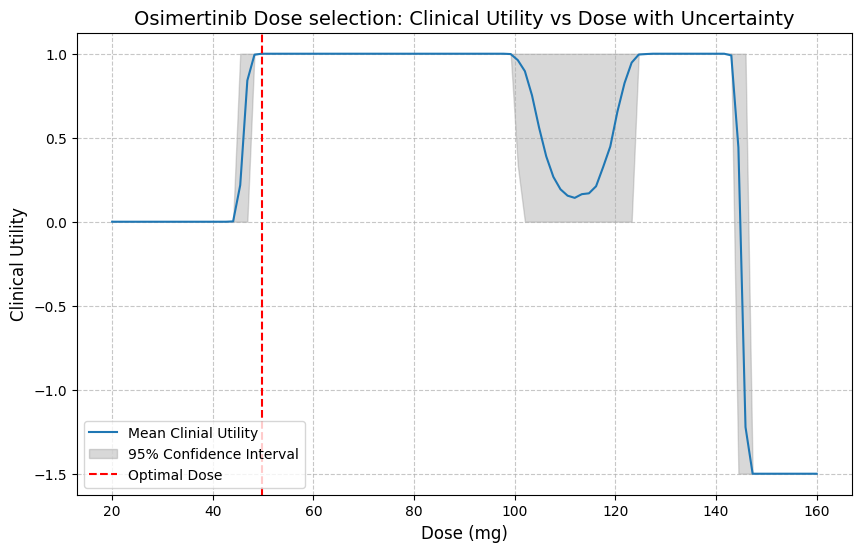

In [33]:
# Visualization with Mean hading
plt.figure(figsize=(10, 6))
plt.plot(dose_range, utilities, label='Mean Clinial Utility')

# Plot the 95% confidence interval as shaded area
plt.fill_between(dose_range.flatten(), lower_ci, upper_ci, color='gray', alpha=0.3, label='95% Confidence Interval')
# Highlight the optimal dose
best_dose_idx=np.argmax(utilities)
plt.axvline(x=dose_range[best_dose_idx], color='red', linestyle='--', label='Optimal Dose')

plt.title('Osimertinib Dose selection: Clinical Utility vs Dose with Uncertainty', fontsize=14)
plt.xlabel('Dose (mg)', fontsize=12)
plt.ylabel('Clinical Utility', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Ｓummary:

Model-based simulations indicate that within the 100 mg to 120 mg dose range, the confidence intervals expand significantly due to the lack of empirical Phase I data. This reflects lower predictive robustness in this specific interval. When combined with the model’s toxicity penalty mechanism for high-dose exposure, the clinical utility curve exhibits localized fluctuations.

In contrast, while the 50 mg dose already demonstrates significant efficacy, it sits precariously close to the 40 mg 'efficacy cliff,' where therapeutic benefit rapidly diminishes.

The 80 mg dose, however, demonstrates superior predictive certainty (characterized by a narrow confidence interval) and is positioned at the center of the therapeutic saturation plateau. This provides the optimal population fault tolerance, ensuring stable efficacy across varying patient phenotypes (e.g., body weight or metabolic clearance).

Based on Gaussian Process modeling of Phase I data, we propose a randomized Phase II trial comparing 40 mg vs. 80 mg. While 80 mg remains the robust selection due to its position in the center of the therapeutic plateau, the 40/50 mg arm serves to satisfy Project Optimus requirements for dose optimization. The AI model identifies 80 mg as the dose with the highest 'Scientific Certainty' (narrowest CI), providing a safety buffer against inter-patient PK variability



100%|██████████| 8/8 [00:00<00:00, 152.04it/s]


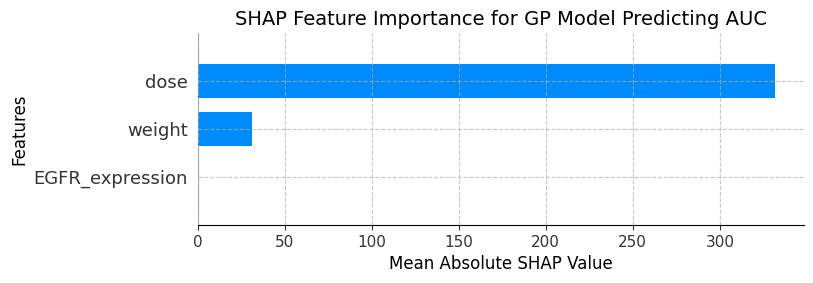

In [34]:
# apply shap to interpret the GP model's predictions across the dose range
features = ['dose', 'weight', 'EGFR_expression']
X= phase1_dose[features]

# define a prediction function for SHAP that takes the dose as input and returns the predicted AUC
def predict_function(x_input):
    # if X_input is DataFreame, convert to numpy array
    if isinstance(x_input, pd.DataFrame):
        x_input = x_input.values
    # only use the mean Predcition for SHAP, ignore the uncertainty for interpretability
    return gp_model.predict(x_input)

# Initialize SHAP explainer with KernelExplainer, GP is not tree-based model
# Using X median as the background dataset for SHAP
explainer = shap.KernelExplainer(predict_function, shap.kmeans(X, 3)) 

# calculate SHAP
# # using k-means to summarize the background dataset
shap_values = explainer.shap_values(X)

# Visualize SHAP values for dose feature
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X, plot_type='bar', show=False)
plt.title('SHAP Feature Importance for GP Model Predicting AUC', fontsize=14)
plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### It means the dose play an important role in determining the AUC, which is consistent with our understanding of PK. The SHAP values for weight and EGFR_expression are lower, suggesting they have less influence on the AUC prediction compared to dose in this model. This insight can help us understand the model's behavior and the relative importance of different features in predicting drug exposure.

### However, we use median of weight and EGFR, we try to use them as variable and run the whole model again 

In [54]:
#  Enhance Utilioty Function with Penality for Toxixicty(Individualized Utility Function
def clinical_utility_individualized(dose, weight, EGFR_expression,model):
    # standardize input for GP


    # input for GP prediction
    input_val=np.array([[dose, weight, EGFR_expression]])

    # Predict AUC and standard deviation for uncertainty estimation
    predicted_auc, sigma = gp_model.predict(input_val, return_std=True)

    # Simulate a distribution (1000 patients, Monte Carlo) of response for this specific patient
    simulated_responses = np.random.normal(predicted_auc, sigma, 1000)

    # Threshold for Osimertinib
    p_efficacy=np.mean(simulated_responses >= 400) # target AUC for efficacy
    p_toxicity=np.mean(simulated_responses >= 1000) # target AUC for toxicity   

    # Reecommended weights based on regulatory preference for safety
    w1=1.0 # weight for efficacy
    w2=2.5 # weight for toxicity
    utility= w1 * p_efficacy - w2 * p_toxicity
    return -utility # minimize negative utility to find optimal dose    
    # 

# Bayesian Style Optimization


In [70]:
# Setup the covariate values for a specific patient (can be personalized based on patient's characteristics)
patient_profile = {'weight': 68, 'EGFR_expression': 1.2}

res = minimize(
    fun=lambda d: clinical_utility_individualized(
        d[0],                           # 優化器嘗試的劑量
        patient_profile['weight'],      # 固定體重
        patient_profile['EGFR_expression'], # 固定基因表現
        gp_model                        # 傳入訓練好的 GP 模型
    ), 
    x0=[80],                            # 起始劑量
    bounds=[(20, 160)],                 # 劑量搜尋範圍
    method='L-BFGS-B'
)

best_dose = res.x[0]
print(f"Optimal Dose: {best_dose:.2f} mg (Utility: {-res.fun:.4f})")


Optimal Dose: 80.00 mg (Utility: 1.0000)


In [71]:
# Build the explainer to interpret the individualized utility function for this specific patient
def predict_individualized(X_input):
    # X_input is expected to be a 2D array with columns [dose, weight, EGFR_expression]
    return gp_model.predict(X_input)

# Initialize Kernel SHAP explainer for the individualized prediction
background = shap.kmeans(X_train, 3) # using k-means to summarize the background dataset
explainer_individualized = shap.KernelExplainer(predict_individualized, background)

# optmal dose for this patient
optimal_input = np.array([[best_dose, patient_profile['weight'], patient_profile['EGFR_expression']]])

# calculate SHAP values for the optimal dose prediction
shap_values_individualized = explainer_individualized.shap_values(optimal_input)



100%|██████████| 1/1 [00:00<00:00, 59.04it/s]


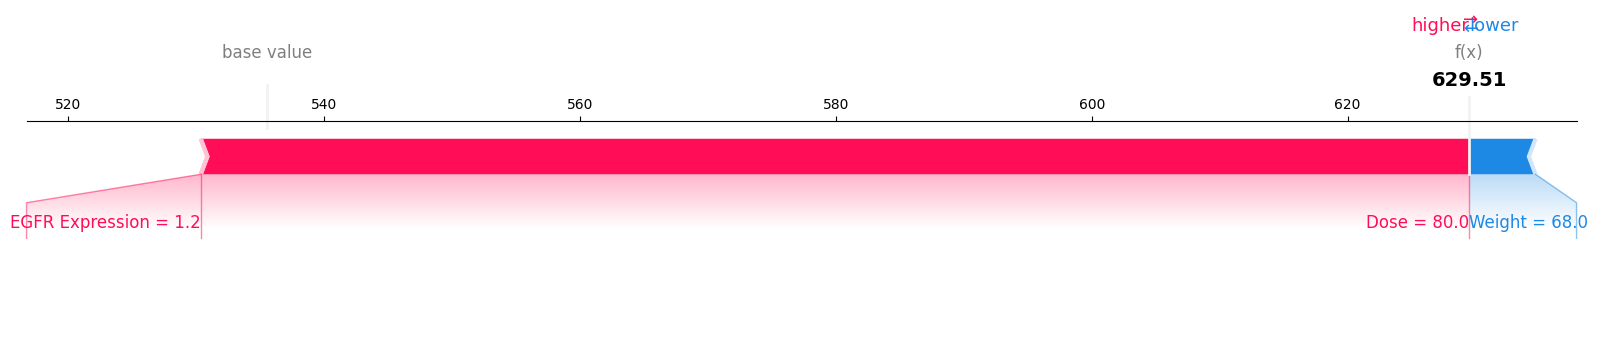

In [72]:
# Visualize SHAP values for the individualized utility function
shap.initjs()
feature_names = ['Dose', 'Weight', 'EGFR Expression']
optimal_input_df = pd.DataFrame(optimal_input, columns=feature_names)
shap.force_plot(explainer_individualized.expected_value, shap_values_individualized, optimal_input_df, feature_names=feature_names, matplotlib=True)


# if the dosage is 80 mg, weight 68kg and EGFR =1.2
1.Dose = 80.0: This is the most powerful "red force" in the chart. Increasing the dose is the most direct factor in raising the drug concentration within the body.

2.EGFR Expression = 1.2: Although its proportion is smaller, at this specific value, the EGFR expression is viewed by the model as a positive factor that slightly increases the AUC.

3.Weight = 68.0: This is the only "blue force" in the chart. It represents that relative to other factors, a body weight of 68 kg acts as a "dilution" or reduction factor for drug exposure in the model, preventing the AUC from skyrocketing excessively.